# Finding grid cells that could be called "coastal" by having a non-zero amount of land (lsm > 0.1) and also at least one neighbor that is fully water (lsm = 0)

In [230]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns



In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

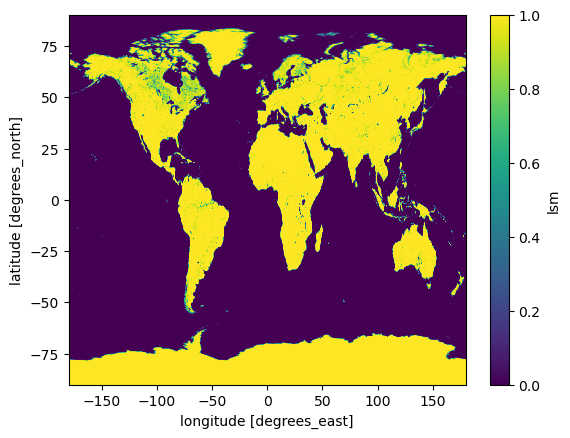

In [62]:
ds.lsm.plot()

# Try to use crafty indexing so I don't have to loop to check all the neighbors of a cell

In [31]:
([float(ds.lsm.lat[0]), float(ds.lsm.lat[-1])])

[90.0, -90.0]

In [30]:
res = 0.25
ds_coastal = ds.where((ds.lsm > 0.1) & # must have some land in the currrent cell
                      (ds.lsm.sel(lat=slice(np.min([float((ds.lsm.lat+res).values), float(ds.lsm.lat[0])]),
                                            np.max([float((ds.lsm.lat-res).values), float(ds.lsm.lat[-1])])), 
                                  lon=slice(np.min([float((ds.lsm.lon+res).values), float(ds.lsm.lon[0])]),
                                            np.max([float((ds.lsm.lon+res).values), float(ds.lsm.lon[-1])]))).isin([0,0]).sum() > 1) # at least one neighbor has lsm=0
                     )

ds_coastal

TypeError: only length-1 arrays can be converted to Python scalars

# Guess I'll have to write a loop

### Something else to consider would be areas with lsm > 0.1 and a low measure of "continentality" (see https://link.springer.com/referenceworkentry/10.1007/1-4020-3266-8_131)

## Amount of land required for each cell when performing neighborhood check = 0.3 (30% land)

In [158]:
%%time

# takes 4 min 

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds.lat.values[:num_lat]
loop_lons = ds.lon.values[:num_lon]

# empty data arrays for coastal boolean
coastal = xr.DataArray(np.full((num_lat,num_lon), False, dtype=bool), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
coastal.attrs["long_name"] = "Boolean value for whether the cell has at least one all water neighbor"
coastal.attrs["units"] = "true/false"

# resolution of grid
res = 0.25

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # is the current cell at least partially land?
        if (bool(ds.lsm.sel(lat=input_lat, lon=input_lon) > 0.3)): 
        
            # check neighborhood and handle boundaries
            # if one cell in the neighborhood has value 0 then it has a water neighbor
            if ((ds.lsm.sel(lat=slice(np.min([input_lat+res, float(ds.lsm.lat[0])]),
                                      np.max([input_lat-res, float(ds.lsm.lat[-1])])), 
                            lon=slice(np.max([input_lon-res, float(ds.lsm.lon[0])]),
                                      np.min([input_lon+res, float(ds.lsm.lon[-1])]))) < 0.2).sum() >= 1):
                # then it is a coastal cell
                coastal.loc[input_lat, input_lon] = True
            else:
                coastal.loc[input_lat, input_lon] = False

        
# results dataset
results_ds = xr.Dataset(data_vars={'Coastal':coastal})

# see results
results_ds

CPU times: user 3min 31s, sys: 38.3 ms, total: 3min 31s
Wall time: 3min 32s


<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB False False False False ... False False False

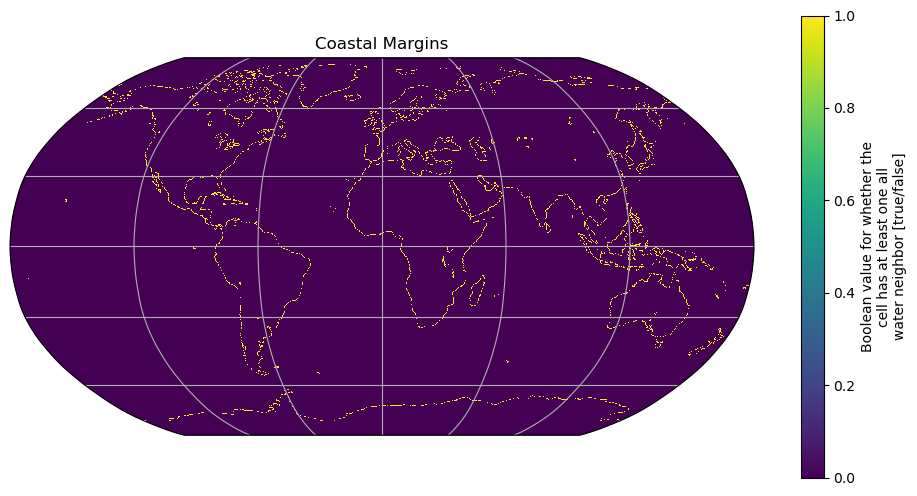

In [159]:

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
#ax.coastlines()
ax.gridlines()

results_ds.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    #cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Coastal Margins")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

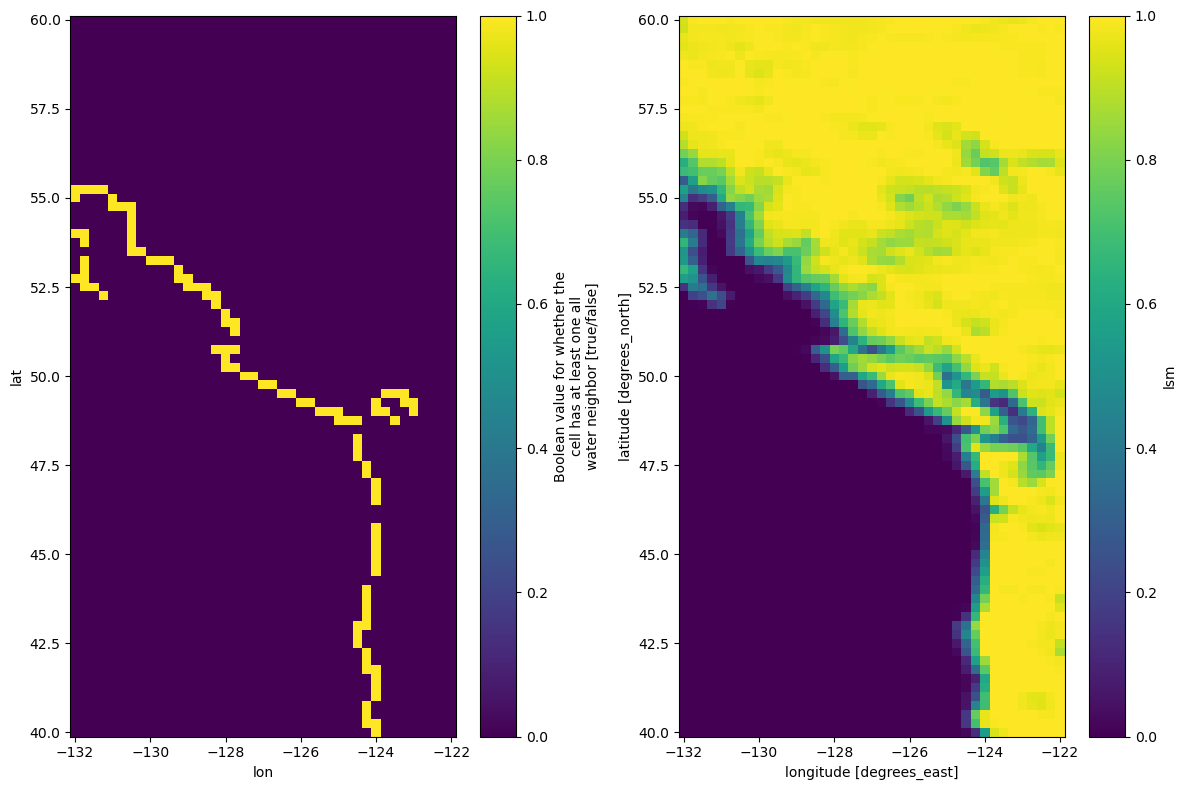

In [179]:
plt.figure(figsize=(12,8))
plt.subplot(121)
results_ds.Coastal.sel(lat=slice(60,40),lon=slice(-132,-122)).plot()
plt.subplot(122)
ds.lsm.sel(lat=slice(60,40),lon=slice(-132,-122)).plot()
plt.tight_layout()
plt.show()

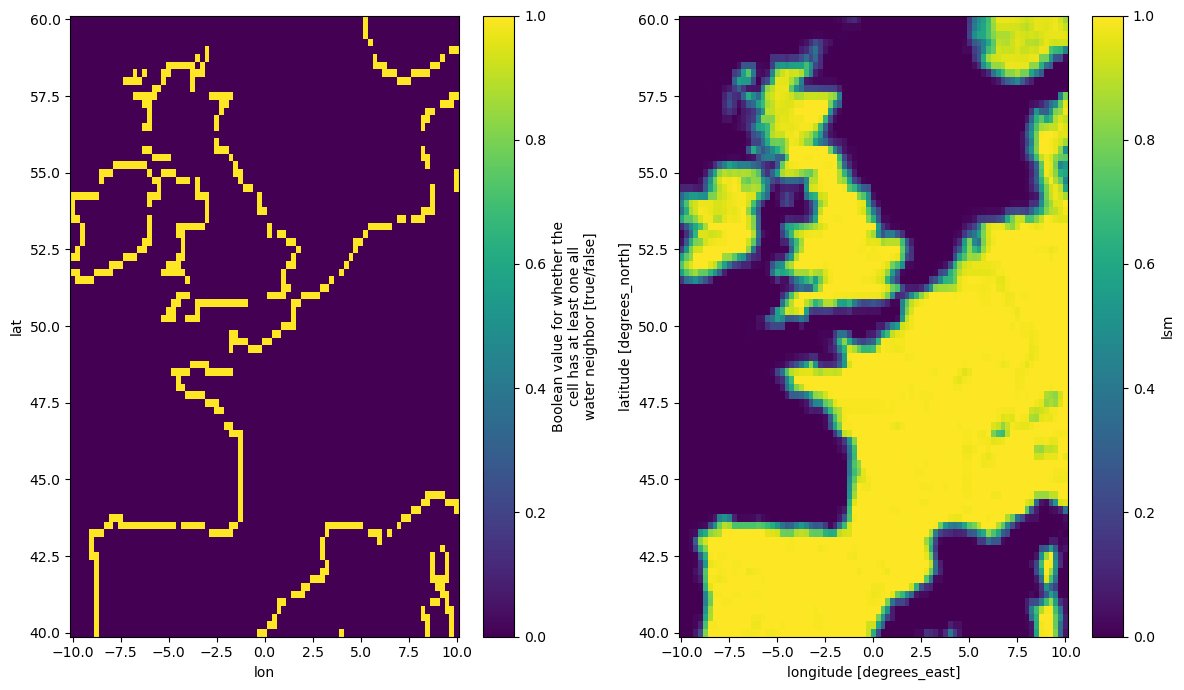

In [181]:
plt.figure(figsize=(12,7))
plt.subplot(121)
results_ds.Coastal.sel(lat=slice(60,40),lon=slice(-10,10)).plot()
plt.subplot(122)
ds.lsm.sel(lat=slice(60,40),lon=slice(-10,10)).plot()
plt.tight_layout()
plt.show()

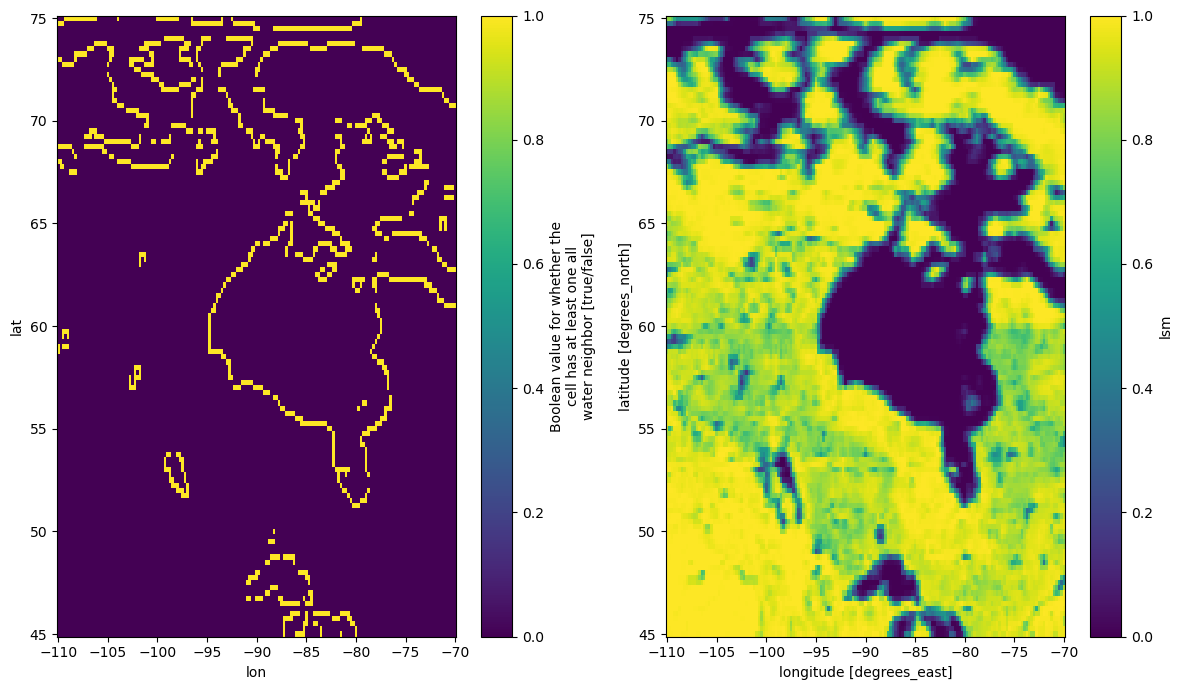

In [186]:
plt.figure(figsize=(12,7))
plt.subplot(121)
results_ds.Coastal.sel(lat=slice(75,45),lon=slice(-110,-70)).plot()
plt.subplot(122)
ds.lsm.sel(lat=slice(75,45),lon=slice(-110,-70)).plot()
plt.tight_layout()
plt.show()

In [187]:
# test_lat=33
# test_lon = -10

# ds.lsm.sel(lat=slice(np.min([test_lat+res, float(ds.lsm.lat[0])]),
#                              np.max([test_lat-res, float(ds.lsm.lat[-1])])), 
#                    lon=slice(np.max([lest_lon-res, float(ds.lsm.lon[0])]),
#                              np.min([lest_lon+res, float(ds.lsm.lon[-1])])))

## Amount of land required for each cell when performing neighborhood check = 0.4 (40% land)

In [188]:
%%time

# takes 4 min 

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds.lat.values[:num_lat]
loop_lons = ds.lon.values[:num_lon]

# empty data arrays for coastal boolean
coastal = xr.DataArray(np.full((num_lat,num_lon), False, dtype=bool), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
coastal.attrs["long_name"] = "Boolean value for whether the cell has at least one all water neighbor"
coastal.attrs["units"] = "true/false"

# resolution of grid
res = 0.25

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # is the current cell at least partially land?
        if (bool(ds.lsm.sel(lat=input_lat, lon=input_lon) > 0.4)): 
        
            # check neighborhood and handle boundaries
            # if one cell in the neighborhood has value 0 then it has a water neighbor
            if ((ds.lsm.sel(lat=slice(np.min([input_lat+res, float(ds.lsm.lat[0])]),
                                      np.max([input_lat-res, float(ds.lsm.lat[-1])])), 
                            lon=slice(np.max([input_lon-res, float(ds.lsm.lon[0])]),
                                      np.min([input_lon+res, float(ds.lsm.lon[-1])]))) < 0.2).sum() >= 1):
                # then it is a coastal cell
                coastal.loc[input_lat, input_lon] = True
            else:
                coastal.loc[input_lat, input_lon] = False

        
# results dataset
results_ds_40 = xr.Dataset(data_vars={'Coastal':coastal})

# see results
results_ds_40

CPU times: user 3min 26s, sys: 64.7 ms, total: 3min 26s
Wall time: 3min 27s


<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB False False False False ... False False False

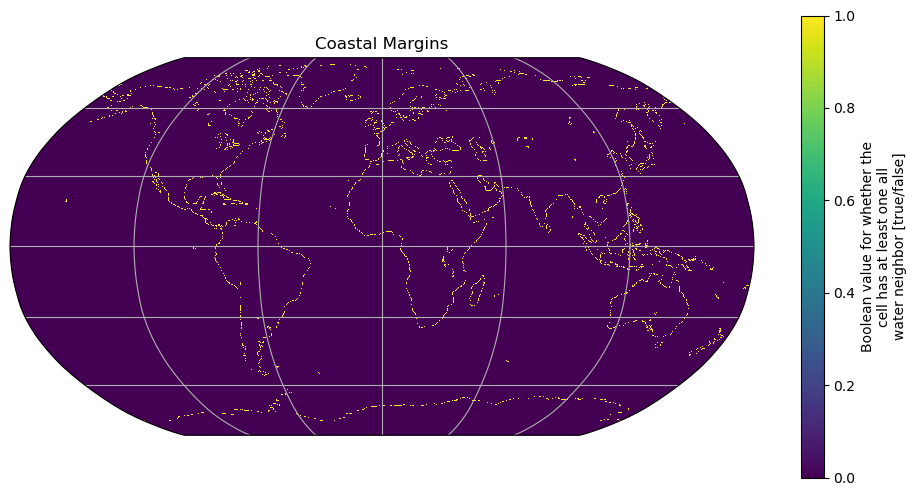

In [189]:

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
#ax.coastlines()
ax.gridlines()

results_ds_40.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    #cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Coastal Margins")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Amount of land required for each cell when performing neighborhood check = 0.3 (30% land) but water cell must be 10% or less

In [193]:
%%time

# takes 4 min 

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds.lat.values[:num_lat]
loop_lons = ds.lon.values[:num_lon]

# empty data arrays for coastal boolean
coastal = xr.DataArray(np.full((num_lat,num_lon), False, dtype=bool), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
coastal.attrs["long_name"] = "Boolean value for whether the cell has at least one all water neighbor"
coastal.attrs["units"] = "true/false"

# resolution of grid
res = 0.25

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # is the current cell at least partially land?
        if (bool(ds.lsm.sel(lat=input_lat, lon=input_lon) > 0.3)): 
        
            # check neighborhood and handle boundaries
            # if one cell in the neighborhood has value 0 then it has a water neighbor
            if ((ds.lsm.sel(lat=slice(np.min([input_lat+res, float(ds.lsm.lat[0])]),
                                      np.max([input_lat-res, float(ds.lsm.lat[-1])])), 
                            lon=slice(np.max([input_lon-res, float(ds.lsm.lon[0])]),
                                      np.min([input_lon+res, float(ds.lsm.lon[-1])]))) <= 0.1).sum() >= 1):
                # then it is a coastal cell
                coastal.loc[input_lat, input_lon] = True
            else:
                coastal.loc[input_lat, input_lon] = False

        
# results dataset
results_ds_3010 = xr.Dataset(data_vars={'Coastal':coastal})

# see results
results_ds_3010

CPU times: user 3min 29s, sys: 58.1 ms, total: 3min 29s
Wall time: 3min 29s


<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB False False False False ... False False False

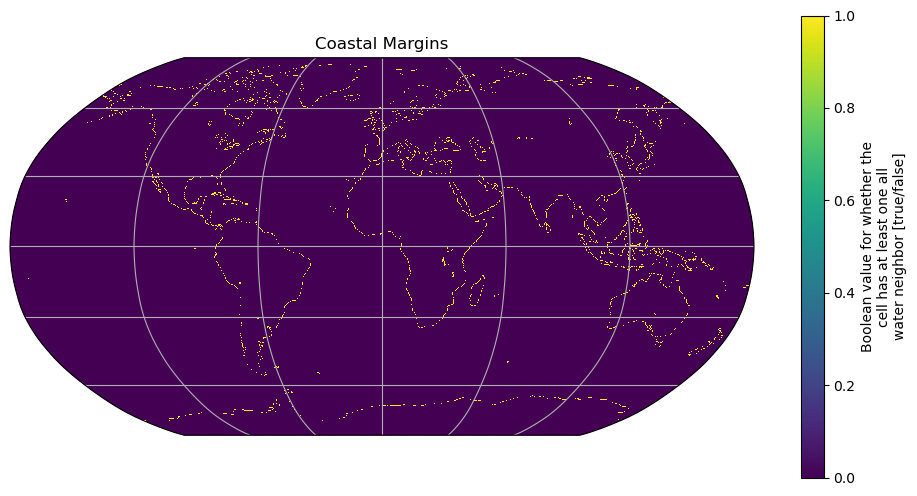

In [194]:

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
#ax.coastlines()
ax.gridlines()

results_ds_3010.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    #cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Coastal Margins")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Amount of land required for each cell when performing neighborhood check = 0.5 (50% land) 

In [ ]:
%%time

# takes 4 min 

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds.lat.values[:num_lat]
loop_lons = ds.lon.values[:num_lon]

# empty data arrays for coastal boolean
coastal = xr.DataArray(np.full((num_lat,num_lon), False, dtype=bool), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
coastal.attrs["long_name"] = "Boolean value for whether the cell has at least one all water neighbor"
coastal.attrs["units"] = "true/false"

# resolution of grid
res = 0.25

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # is the current cell at least partially land?
        if (bool(ds.lsm.sel(lat=input_lat, lon=input_lon) > 0.5)): 
        
            # check neighborhood and handle boundaries
            # if one cell in the neighborhood has value 0 then it has a water neighbor
            if ((ds.lsm.sel(lat=slice(np.min([input_lat+res, float(ds.lsm.lat[0])]),
                                      np.max([input_lat-res, float(ds.lsm.lat[-1])])), 
                            lon=slice(np.max([input_lon-res, float(ds.lsm.lon[0])]),
                                      np.min([input_lon+res, float(ds.lsm.lon[-1])]))) < 0.2).sum() >= 1):
                # then it is a coastal cell
                coastal.loc[input_lat, input_lon] = True
            else:
                coastal.loc[input_lat, input_lon] = False

        
# results dataset
results_ds_50 = xr.Dataset(data_vars={'Coastal':coastal})

# see results
results_ds_50

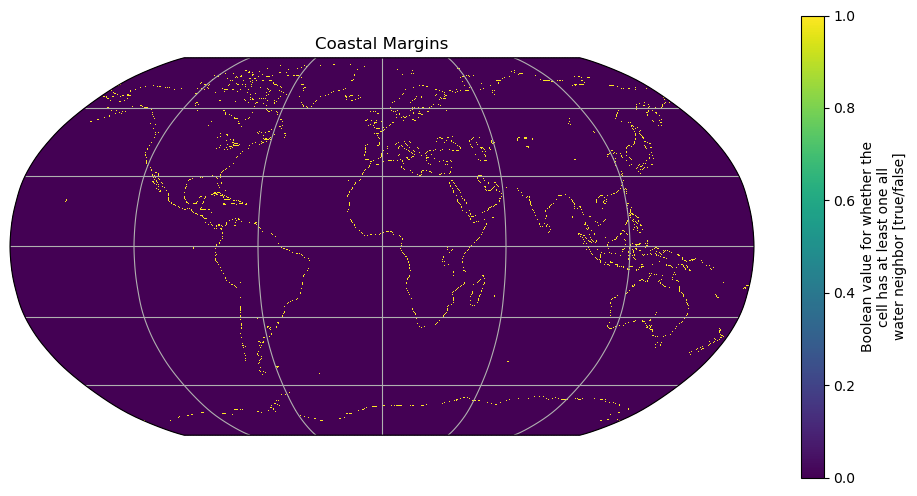

In [191]:

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
#ax.coastlines()
ax.gridlines()

results_ds_50.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    #cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Coastal Margins")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Amount of land required for each cell when performing neighborhood check = 0.2 (20% land) but water cell must be 10% or less

In [196]:
%%time

# takes 4 min 

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds.lat.values[:num_lat]
loop_lons = ds.lon.values[:num_lon]

# empty data arrays for coastal boolean
coastal = xr.DataArray(np.full((num_lat,num_lon), False, dtype=bool), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
coastal.attrs["long_name"] = "Boolean value for whether the cell has at least one all water neighbor"
coastal.attrs["units"] = "true/false"

# resolution of grid
res = 0.25

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # is the current cell at least partially land?
        if (bool(ds.lsm.sel(lat=input_lat, lon=input_lon) > 0.2)): 
        
            # check neighborhood and handle boundaries
            # if one cell in the neighborhood has value 0 then it has a water neighbor
            if ((ds.lsm.sel(lat=slice(np.min([input_lat+res, float(ds.lsm.lat[0])]),
                                      np.max([input_lat-res, float(ds.lsm.lat[-1])])), 
                            lon=slice(np.max([input_lon-res, float(ds.lsm.lon[0])]),
                                      np.min([input_lon+res, float(ds.lsm.lon[-1])]))) <= 0.1).sum() >= 1):
                # then it is a coastal cell
                coastal.loc[input_lat, input_lon] = True
            else:
                coastal.loc[input_lat, input_lon] = False

        
# results dataset
results_ds_2010 = xr.Dataset(data_vars={'Coastal':coastal})

# see results
results_ds_2010

CPU times: user 3min 31s, sys: 46.6 ms, total: 3min 31s
Wall time: 3min 32s


<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB False False False False ... False False False

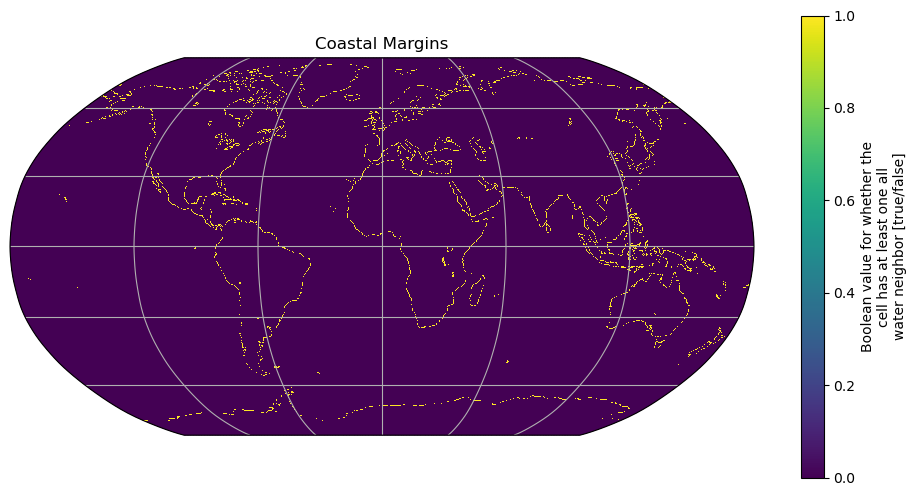

In [197]:

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
#ax.coastlines()
ax.gridlines()

results_ds_2010.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    #cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Coastal Margins")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## plot each of those thresholds for a couple of potentially challenging regions

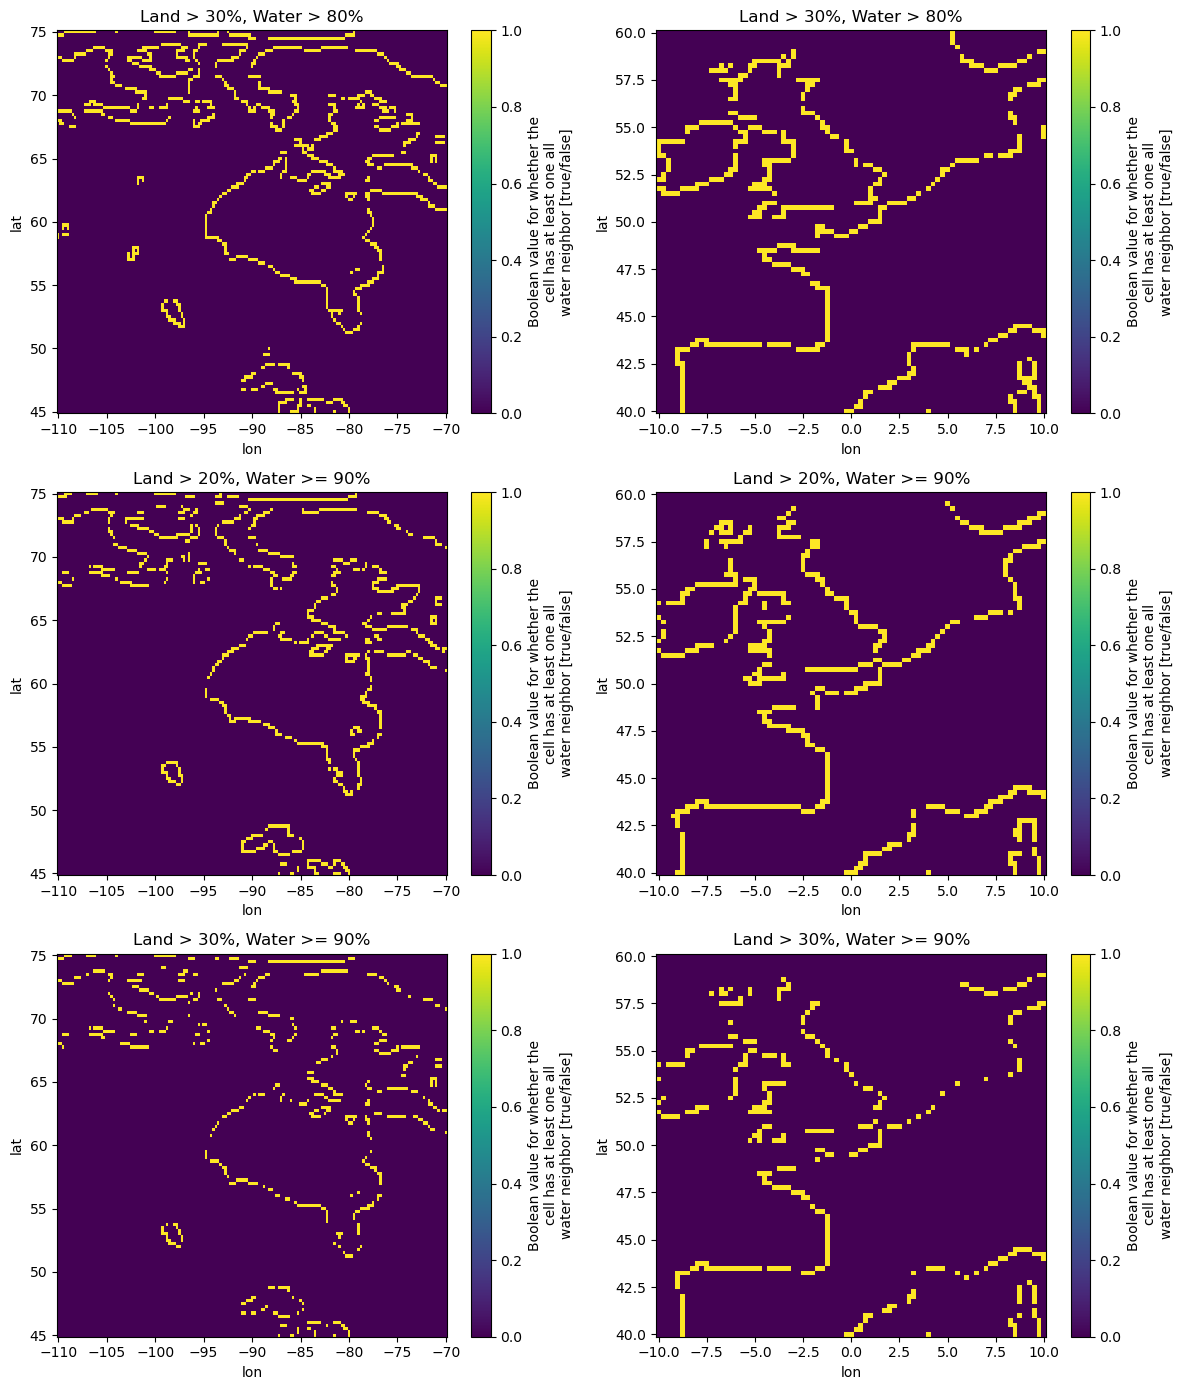

In [204]:
plt.figure(figsize=(12,14))
plt.subplot(321)
results_ds.Coastal.sel(lat=slice(75,45),lon=slice(-110,-70)).plot()
plt.title("Land > 30%, Water > 80%")
plt.subplot(322)
results_ds.Coastal.sel(lat=slice(60,40),lon=slice(-10,10)).plot()
plt.title("Land > 30%, Water > 80%")
plt.subplot(323)
results_ds_2010.Coastal.sel(lat=slice(75,45),lon=slice(-110,-70)).plot()
plt.title("Land > 20%, Water >= 90%")
plt.subplot(324)
results_ds_2010.Coastal.sel(lat=slice(60,40),lon=slice(-10,10)).plot()
plt.title("Land > 20%, Water >= 90%")
plt.subplot(325)
results_ds_3010.Coastal.sel(lat=slice(75,45),lon=slice(-110,-70)).plot()
plt.title("Land > 30%, Water >= 90%")
plt.subplot(326)
results_ds_3010.Coastal.sel(lat=slice(60,40),lon=slice(-10,10)).plot()
plt.title("Land > 30%, Water >= 90%")
plt.tight_layout()
plt.show()

### Looks like the central cell containing > 30% land and the neighbor cell requiring at least 80% water looks the best - check what % of total grid cells each of these includes

In [207]:
results_ds.Coastal.sum()/results_ds.Coastal.count(), results_ds_2010.Coastal.sum()/results_ds.Coastal.count(), results_ds_3010.Coastal.sum()/results_ds.Coastal.count()

(<xarray.DataArray 'Coastal' ()> Size: 8B
 array(0.01702304),
 <xarray.DataArray 'Coastal' ()> Size: 8B
 array(0.01599149),
 <xarray.DataArray 'Coastal' ()> Size: 8B
 array(0.01174199))

### roughly 1.7% of all grid cells are classified as "coastal" by the 30/80 thresholds

## Nicer maps

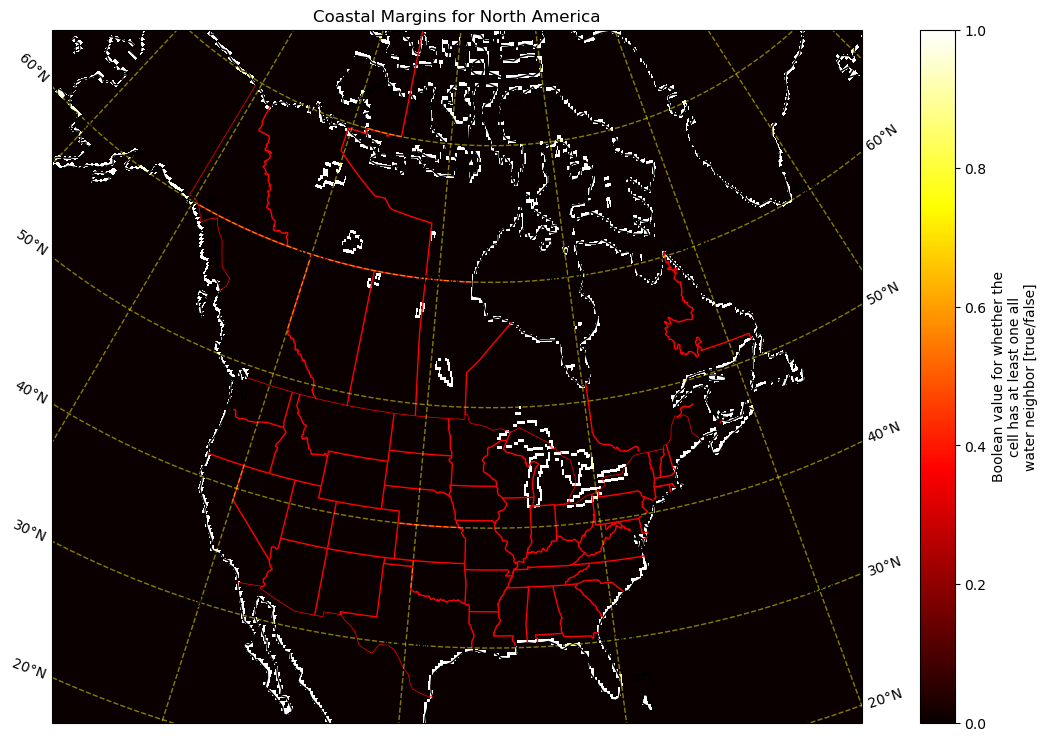

In [223]:

central_longitude = -(91 + 52 / 60)
central_latitude = 40

fig = plt.figure(figsize=(15,9))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='yellow', alpha=0.5, linestyle='--')

dataplot = results_ds.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    cmap="hot",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((-130, -60, 20, 75))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none', edgecolor='red')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='red')
#ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='red')
ax.add_feature(provinces_50m)

plt.title("Coastal Margins for North America")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



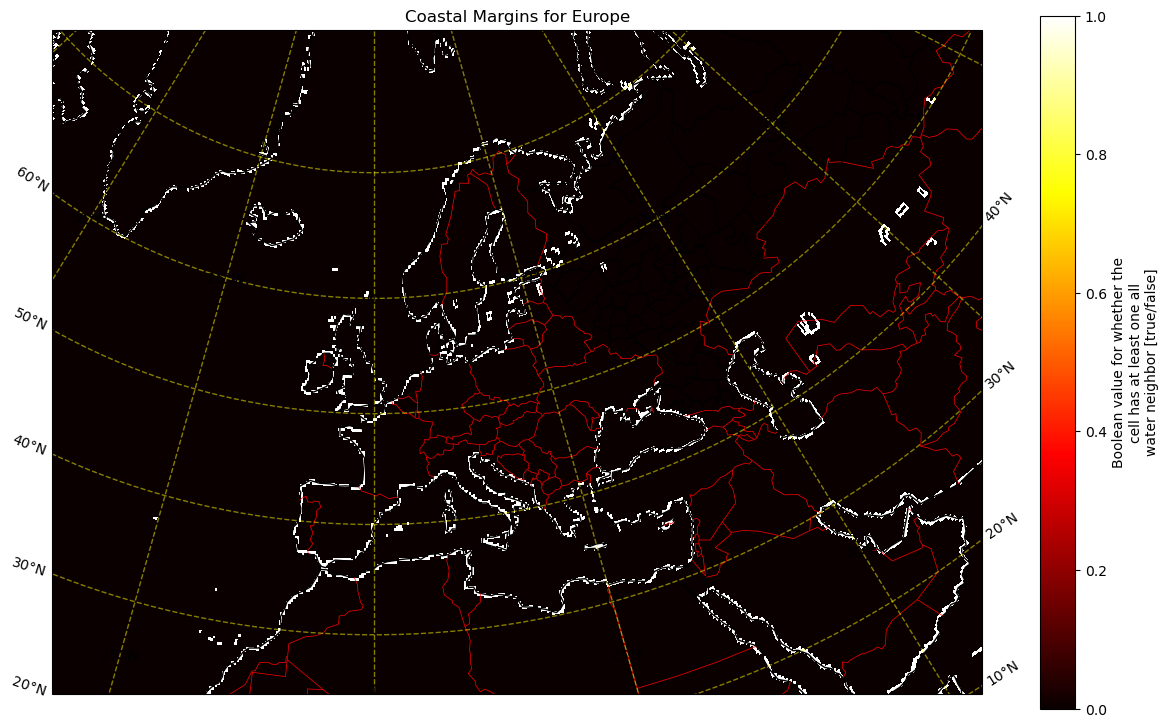

In [224]:

central_longitude = 0
central_latitude = 40

fig = plt.figure(figsize=(15,9))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='yellow', alpha=0.5, linestyle='--')

dataplot = results_ds.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    cmap="hot",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((-30, 60, 20, 75))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='red')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)

plt.title("Coastal Margins for Europe")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



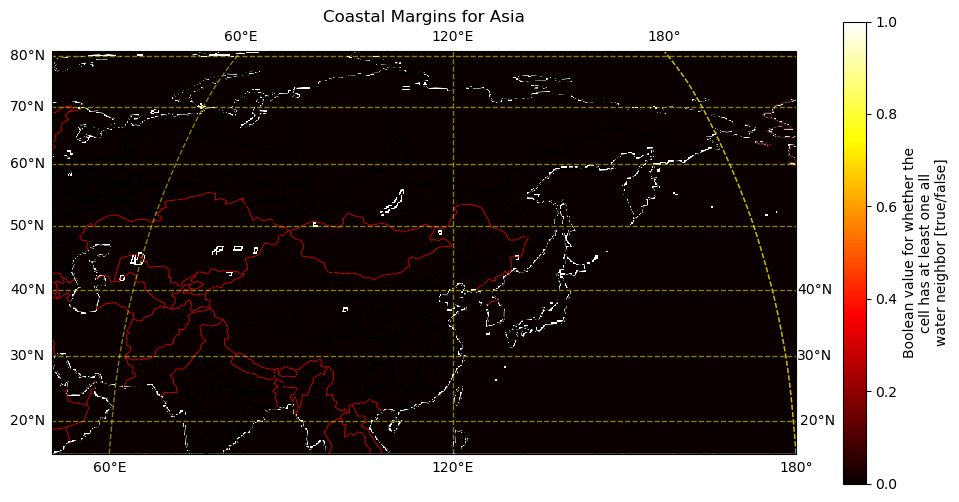

In [225]:

central_longitude = 120
central_latitude = -30

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=central_longitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='yellow', alpha=0.5, linestyle='--')

dataplot = results_ds.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    cmap="hot",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((50, 180, 15, 70))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='red')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)

plt.title("Coastal Margins for Asia")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



## Write out the coastal margins for use in data processing

In [226]:
# write those results out for later use
output_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-CoastalMargins.nc'
results_ds.to_netcdf(output_path)



In [228]:
ds, results_ds

(<xarray.Dataset> Size: 8MB
 Dimensions:  (lat: 721, lon: 1440)
 Coordinates:
   * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
   * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
 Data variables:
     lsm      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0 1.0,
 <xarray.Dataset> Size: 1MB
 Dimensions:  (lat: 721, lon: 1440)
 Coordinates:
   * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
   * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
 Data variables:
     Coastal  (lat, lon) bool 1MB False False False False ... False False False)

## write out the full data set for coastal areas now including the coastal margin boolean

In [237]:
%%time

# takes ~4 min to load

# start with one year and lsm then coastal and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds) # add lsm
ds_base = ds_base.merge(results_ds) # add coastal flag
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,2024,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds)
    ds_i = ds_i.merge(results_ds)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 1min 32s, sys: 2min 9s, total: 3min 42s
Wall time: 4min 24s


<xarray.Dataset> Size: 6GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 216.0 216.0
    SummerEnd     (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 247.0 247.0
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 69.28 69.28
    SummerLength  (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 32.0 32.0 32.0
    SummerRMSE    (time, lat, lon) float64 523MB 6.906 6.906 ... 5.387 5.387
    SummerR2      (time, lat, lon) float64 523MB 0.5105 0.5105 ... 0.735 0.735
    SummerMeanT   (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 272.9 272.9
    SummerMeanHS  (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 2.165 2.165
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [248]:
# re-add attributes which get lost on merge apparently
ds_base.SummerStart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
ds_base.SummerStart.attrs["units"] = "Day of year"

ds_base.SummerEnd.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
ds_base.SummerEnd.attrs["units"] = "Day of year"

ds_base.SummerLength.attrs["long_name"] = "Duration of summer for the year"
ds_base.SummerLength.attrs["units"] = "Days"

ds_base.SummerTmax.attrs["long_name"] = "Day of max mean temp during summer for the year"
ds_base.SummerTmax.attrs["units"] = "Day of year"

ds_base.SummerHeat.attrs["long_name"] = "Accumulated heat during summer for the year"
ds_base.SummerHeat.attrs["units"] = "Degree-Days"

ds_base.SummerRMSE.attrs["long_name"] = "Root mean squared error of polynomial fit"
ds_base.SummerRMSE.attrs["units"] = "Degrees [K]"

ds_base.SummerR2.attrs["long_name"] = "Coefficient of determination (R-squared) of polynomial fit"
ds_base.SummerR2.attrs["units"] = "Variance explained"

ds_base.SummerMeanT.attrs["long_name"] = "Mean temperature during the summer period"
ds_base.SummerMeanT.attrs["units"] = "Degrees [K]"

ds_base.lsm.attrs["long_name"] = "Land-sea mask - a measure of the amount of land in the cell"
ds_base.lsm.attrs["units"] = "(0 - 1)"

ds_base.SummerMeanHS.attrs["long_name"] = "Mean HS temperature during the summer period"
ds_base.SummerMeanHS.attrs["units"] = "Degrees [K]"

###
### also cast the Coastal as boolean?
###
ds_base.Coastal.values = ds_base.Coastal.values.astype(bool)
ds_base.Coastal.attrs["long_name"] = "Boolean value for whether a >30% land cell has at least one >80% water neighbor"
ds_base.Coastal.attrs["units"] = "true/false"

ds_base

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 216.0 216.0
    SummerEnd     (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 247.0 247.0
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 69.28 69.28
    SummerLength  (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 32.0 32.0 32.0
    SummerRMSE    (time, lat, lon) float64 523MB 6.906 6.906 ... 5.387 5.387
    SummerR2      (time, lat, lon) float64 523MB 0.5105 0.5105 ... 0.735 0.735
    SummerMeanT   (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 272.9 272.9
    SummerMeanHS  (time, lat, lon) float64 523MB 0.0 0.0 0.0 ... 2.165 2.165
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) bool 65MB False False False ... False False

In [252]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_base.to_netcdf(output_path)

# create a COASTAL data file similar to the LAND and OCEAN ones we have so far as well
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_COASTAL_summer_stats.nc'
ds_coastal = ds_base.where(ds_base.Coastal)
ds_coastal.to_netcdf(output_path)



In [259]:
! ls -al "../../../Data/ERA5-global/Analysis/New/"

total 69841048
drwxr-xr-x@ 79 tedscott  staff        2528 Aug  9 15:37 .
drwxr-xr-x@ 40 tedscott  staff        1280 Jul  4 19:09 ..
-rw-r--r--@  1 tedscott  staff        6148 Jul  3 21:42 .DS_Store
-rw-r--r--@  1 tedscott  staff    58172778 Jul  7 19:38 1960_summer_stats.nc
-rw-r--r--@  1 tedscott  staff  4634738022 Jul 18 12:43 1961-2022_LAND_summer_stats.nc
-rw-r--r--@  1 tedscott  staff  4634738022 Jul 18 12:43 1961-2022_OCEAN_summer_stats.nc
-rw-r--r--   1 tedscott  staff  5298175103 Aug  9 15:37 1961-2023_ALL_summer_stats.nc
-rw-r--r--@  1 tedscott  staff    33249536 Jul 31 11:26 1961-2023_AccHeatTrends.nc
-rw-r--r--   1 tedscott  staff  5756037130 Aug  9 15:37 1961-2023_COASTAL_summer_stats.nc
-rw-r--r--@  1 tedscott  staff  5232765083 Jul 30 10:53 1961-2023_LAND_summer_stats.nc
-rw-r--r--@  1 tedscott  staff    33249536 Aug  5 12:13 1961-2023_LengthTrends.nc
-rw-r--r--@  1 tedscott  staff  5232765083 Jul 30 10:53 1961-2023_OCEAN_summer_stats.nc
-rw-r--r--@  1 tedscott  staff    

In [249]:
ds_coastal = ds_base.where(ds_base.Coastal)
ds_coastal

<xarray.Dataset> Size: 6GB
Dimensions:       (time: 63, lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerEnd     (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerTmax    (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerHeat    (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerLength  (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerRMSE    (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerR2      (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerMeanT   (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    SummerMeanHS  (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    lsm           (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan
    Coastal       (time, lat, lon) float64 523MB nan nan nan nan ... nan nan nan

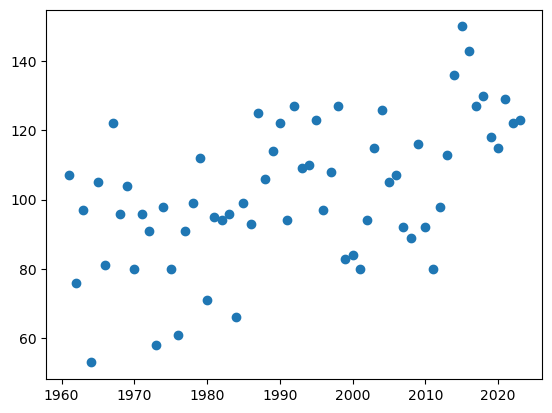

In [251]:
plt.figure()
plt.scatter(ds_coastal.time.dt.year.values, ds_coastal.SummerLength.sel(lat=49, lon=-123))

# OK, can now make plots of land vs ocean vs coastal margins!

## One other suggestion of Simon's - use a landsea mask to stamp out the clearly continental areas but needs to be one that ignores inland waters